# Build Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers

In [ ]:
!pip install ohmeow-blurr -q
!pip install bert-score -q
!pip install sacremoses

import pandas as pd
import torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.5/887.5 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.6/536.6 kB 37.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 23.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 44.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.3/38.3 MB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 16.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 20.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━

In [ ]:
from fastai.text.all import *
from blurr.text.data.all import *
from blurr.text.modeling.all import *
import nltk
nltk.download('punkt')

/usr/local/lib/python3.10/dist-packages/blurr/text/modeling/question_answering.py:31: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  squad_metric = load_metric("squad")
/usr/local/lib/python3.10/dist-packages/datasets/load.py:753: FutureWarning: The repository for squad contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.17.0/metrics/squad/squad.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import numpy as np
import pandas as pd
import csv

In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers.activations import ACT2FN
from transformers import BartTokenizer, AutoModel, BartForConditionalGeneration, AdamW, BartForCausalLM, BartModel
from transformers.models.bart.modeling_bart import BartDecoderLayer, BartEncoderLayer, BartAttention, BartPretrainedModel, BartLearnedPositionalEmbedding
from transformers.models.bart.configuration_bart import BartConfig
from transformers.modeling_outputs import BaseModelOutputWithPastAndCrossAttentions, BaseModelOutput

In [ ]:
tokenizer = BartTokenizer.from_pretrained('facebook/bart-large-cnn')

class SimplificationDataset(torch.utils.data.Dataset):
    def __init__(self, source_sentences, target_sentences, tokenizer):
        self.source_sentences = source_sentences
        self.target_sentences = target_sentences
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.source_sentences)

    def __getitem__(self, idx):
        source_sentence = self.source_sentences[idx]
        target_sentence = self.target_sentences[idx]

        source_encoding = self.tokenizer(source_sentence, max_length=1024, padding="max_length", truncation=True, return_tensors='pt')
        target_encoding = self.tokenizer(target_sentence, max_length=1024, padding="max_length", truncation=True, return_tensors='pt')


        return {
            'input_ids': source_encoding['input_ids'][0],
            'attention_mask': source_encoding['attention_mask'][0],
            'target_ids': target_encoding['input_ids'][0],
            'target_attention_mask': target_encoding['attention_mask'][0]
            }

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/DATA/train_ASSET_preprocess.csv')
df_train.head()

,Unnamed: 0.1,Unnamed: 0,original,simplifications
0,0,0,"adjacent counties are marin ( to the south ) , mendocino ( to the north ) , lake ( northeast ) , napa ( to the east ) , and solano and contra costa ( to the southeast ) .","countries next to it are marin , mendocino , lake , napa , solano , and contra costa ."
1,1,1,"adjacent counties are marin ( to the south ) , mendocino ( to the north ) , lake ( northeast ) , napa ( to the east ) , and solano and contra costa ( to the southeast ) .","nearby counties are marin , mendocino , lake , napa , and solano and contra costa ."
2,2,2,"adjacent counties are marin ( to the south ) , mendocino ( to the north ) , lake ( northeast ) , napa ( to the east ) , and solano and contra costa ( to the southeast ) .","adjacent counties are marin , mendocino , lake , napa , solano and contra costa ."
3,3,3,"adjacent counties are marin ( to the south ) , mendocino ( to the north ) , lake ( northeast ) , napa ( to the east ) , and solano and contra costa ( to the southeast ) .","neighboring counties are marin , mendocino , lake , napa , solano , and contra costa ."
4,4,4,"adjacent counties are marin ( to the south ) , mendocino ( to the north ) , lake ( northeast ) , napa ( to the east ) , and solano and contra costa ( to the southeast ) .","adjacent counties are marin ( south ) , mendocino ( north ) , lake ( northeast ) , and napa ( east ) . solano and contra costa are to the southeast ."


In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers.activations import ACT2FN
from transformers import BartTokenizer, AutoModel, AdamW, BartForCausalLM, BartModel
from transformers.models.bart.modeling_bart import BartDecoder, BartEncoder, BartDecoderLayer, BartEncoderLayer, BartAttention, BartPretrainedModel, BartLearnedPositionalEmbedding
from transformers.models.bart.configuration_bart import BartConfig
from transformers.modeling_outputs import BaseModelOutputWithPastAndCrossAttentions, BaseModelOutput, Seq2SeqLMOutput, Seq2SeqModelOutput

In [ ]:
def _expand_mask(mask, dtype, tgt_len = None):
    """
    Expands attention_mask from `[bsz, seq_len]` to `[bsz, 1, tgt_seq_len, src_seq_len]`.
    """
    bsz, src_len = mask.size()
    tgt_len = tgt_len if tgt_len is not None else src_len

    expanded_mask = mask[:, None, None, :].expand(bsz, 1, tgt_len, src_len).to(dtype)

    inverted_mask = 1.0 - expanded_mask

    return inverted_mask.masked_fill(inverted_mask.to(torch.bool), torch.finfo(dtype).min)

In [ ]:
def shift_tokens_right(input_ids, pad_token_id, decoder_start_token_id):
    """
    Shift input ids one token to the right.
    """
    shifted_input_ids = input_ids.new_zeros(input_ids.shape)
    shifted_input_ids[:, 1:] = input_ids[:, :-1].clone()
    shifted_input_ids[:, 0] = decoder_start_token_id

    if pad_token_id is None:
        raise ValueError("self.model.config.pad_token_id has to be defined.")
    # replace possible -100 values in labels by `pad_token_id`
    shifted_input_ids.masked_fill_(shifted_input_ids == -100, pad_token_id)

    return shifted_input_ids

In [ ]:
def _make_causal_mask(
    input_ids_shape, dtype, device, past_key_values_length = 0
):
    """
    Make causal mask used for bi-directional self-attention.
    """
    bsz, tgt_len = input_ids_shape
    mask = torch.full((tgt_len, tgt_len), torch.tensor(torch.finfo(dtype).min, device=device), device=device)
    mask_cond = torch.arange(mask.size(-1), device=device)
    mask.masked_fill_(mask_cond < (mask_cond + 1).view(mask.size(-1), 1), 0)
    mask = mask.to(dtype)

    if past_key_values_length > 0:
        mask = torch.cat([torch.zeros(tgt_len, past_key_values_length, dtype=dtype, device=device), mask], dim=-1)
    return mask[None, None, :, :].expand(bsz, 1, tgt_len, tgt_len + past_key_values_length)

In [ ]:
class BartEncoder(BartPretrainedModel):
    """
    Transformer encoder consisting of *config.encoder_layers* self attention layers. Each layer is a
    [`BartEncoderLayer`].
    Args:
        config: BartConfig
        embed_tokens (nn.Embedding): output embedding
    """

    def __init__(self, config: BartConfig, embed_tokens = None):
        super().__init__(config)

        self.dropout = config.dropout
        self.layerdrop = config.encoder_layerdrop

        embed_dim = config.d_model
        self.padding_idx = config.pad_token_id
        self.max_source_positions = config.max_position_embeddings
        self.embed_scale = math.sqrt(embed_dim) if config.scale_embedding else 1.0

        self.embed_tokens = nn.Embedding(config.vocab_size, embed_dim, self.padding_idx)

        if embed_tokens is not None:
            self.embed_tokens.weight = embed_tokens.weight

        self.embed_positions = BartLearnedPositionalEmbedding(
            config.max_position_embeddings,
            embed_dim,
        )
        self.layers = nn.ModuleList([BartEncoderLayer(config) for _ in range(12)])
        self.layernorm_embedding = nn.LayerNorm(embed_dim)

        self.gradient_checkpointing = False
        # Initialize weights and apply final processing
        self.post_init()

    def get_input_embeddings(self):
        return self.embed_tokens

    def set_input_embeddings(self, value):
        self.embed_tokens = value

    def forward(
        self,
        input_ids = None,
        attention_mask = None,
        head_mask = None,
        inputs_embeds = None,
        output_attentions = None,
        output_hidden_states = True,
        return_dict = None,
    ):

        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = (
            output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        )
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        # retrieve input_ids and inputs_embeds
        if input_ids is not None and inputs_embeds is not None:
            raise ValueError("You cannot specify both input_ids and inputs_embeds at the same time")
        elif input_ids is not None:
            input = input_ids
            input_ids = input_ids.view(-1, input_ids.shape[-1])
        elif inputs_embeds is not None:
            input = inputs_embeds[:, :, -1]
        else:
            raise ValueError("You have to specify either input_ids or inputs_embeds")

        if inputs_embeds is None:
            inputs_embeds = self.embed_tokens(input_ids) * self.embed_scale

        embed_pos = self.embed_positions(input)
        embed_pos = embed_pos.to(inputs_embeds.device)

        hidden_states = inputs_embeds + embed_pos
        hidden_states = self.layernorm_embedding(hidden_states)
        hidden_states = nn.functional.dropout(hidden_states, p=self.dropout, training=self.training)

        # expand attention_mask
        if attention_mask is not None:
            # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
            attention_mask = _expand_mask(attention_mask, inputs_embeds.dtype)

        encoder_states = ()
        all_attentions = () if output_attentions else None

        # check if head_mask has a correct number of layers specified if desired
        if head_mask is not None:
            if head_mask.size()[0] != (len(self.layers)):
                raise ValueError(
                    f"The head_mask should be specified for {len(self.layers)} layers, but it is for"
                    f" {head_mask.size()[0]}."
                )

        for idx, encoder_layer in enumerate(self.layers):

            encoder_states = encoder_states + (hidden_states,)
            # add LayerDrop (see https://arxiv.org/abs/1909.11556 for description)
            dropout_probability = random.uniform(0, 1)
            if self.training and (dropout_probability < self.layerdrop):  # skip the layer
                layer_outputs = (None, None)
            else:
                if self.gradient_checkpointing and self.training:

                    def create_custom_forward(module):
                        def custom_forward(*inputs):
                            return module(*inputs, output_attentions)

                        return custom_forward

                    layer_outputs = torch.utils.checkpoint.checkpoint(
                        create_custom_forward(encoder_layer),
                        hidden_states,
                        attention_mask,
                        (head_mask[idx] if head_mask is not None else None),
                    )
                else:
                    layer_outputs = encoder_layer(
                        hidden_states,
                        attention_mask,
                        layer_head_mask=(head_mask[idx] if head_mask is not None else None),
                        output_attentions=output_attentions,
                    )

                hidden_states = layer_outputs[0]

            if output_attentions:
                all_attentions = all_attentions + (layer_outputs[1],)


        encoder_states = encoder_states + (hidden_states,)

        if not return_dict:
            return tuple(v for v in [hidden_states, encoder_states, all_attentions] if v is not None)
        return BaseModelOutput(
            last_hidden_state=hidden_states, hidden_states=encoder_states, attentions=all_attentions
        )

/usr/local/lib/python3.10/dist-packages/transformers/models/bart/modeling_bart.py:755: FutureWarning: The class `PretrainedBartModel` has been depreciated, please use `BartPreTrainedModel` instead.
  warnings.warn(


In [ ]:
class BartDecoder(BartPretrainedModel):
    """
    Transformer decoder consisting of *config.decoder_layers* layers. Each layer is a [`BartDecoderLayer`]
    Args:
        config: BartConfig
        embed_tokens (nn.Embedding): output embedding
    """

    def __init__(self, config: BartConfig, embed_tokens = None):
        super().__init__(config)
        self.dropout = config.dropout
        self.layerdrop = config.decoder_layerdrop
        self.padding_idx = config.pad_token_id
        self.max_target_positions = config.max_position_embeddings
        self.embed_scale = math.sqrt(config.d_model) if config.scale_embedding else 1.0

        self.embed_tokens = nn.Embedding(config.vocab_size, config.d_model, self.padding_idx)

        if embed_tokens is not None:
            self.embed_tokens.weight = embed_tokens.weight

        self.embed_positions = BartLearnedPositionalEmbedding(
            config.max_position_embeddings,
            config.d_model,
        )
        self.layers = nn.ModuleList([BartDecoderLayer(config) for _ in range(12)])
        self.layernorm_embedding = nn.LayerNorm(config.d_model)

        self.gradient_checkpointing = False
        # Initialize weights and apply final processing
        self.post_init()

    def get_input_embeddings(self):
        return self.embed_tokens

    def set_input_embeddings(self, value):
        self.embed_tokens = value

    def _prepare_decoder_attention_mask(self, attention_mask, input_shape, inputs_embeds, past_key_values_length):
        # create causal mask
        # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
        combined_attention_mask = None
        if input_shape[-1] > 1:
            combined_attention_mask = _make_causal_mask(
                input_shape,
                inputs_embeds.dtype,
                device=inputs_embeds.device,
                past_key_values_length=past_key_values_length,
            )

        if attention_mask is not None:
            # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
            expanded_attn_mask = _expand_mask(attention_mask, inputs_embeds.dtype, tgt_len=input_shape[-1]).to(
                inputs_embeds.device
            )
            combined_attention_mask = (
                expanded_attn_mask if combined_attention_mask is None else expanded_attn_mask + combined_attention_mask
            )

        return combined_attention_mask

    def forward(
        self,
        input_ids = None,
        attention_mask = None,
        encoder_hidden_states = None,
        encoder_attention_mask = None,
        head_mask = None,
        cross_attn_head_mask = None,
        past_key_values = None,
        latent_key_values = None,
        inputs_embeds = None,
        use_cache = None,
        output_attentions = None,
        output_hidden_states = None,
        return_dict = None,
    ) :

        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = (
            output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        )
        use_cache = use_cache if use_cache is not None else self.config.use_cache
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        # retrieve input_ids and inputs_embeds
        if input_ids is not None and inputs_embeds is not None:
            raise ValueError("You cannot specify both decoder_input_ids and decoder_inputs_embeds at the same time")
        elif input_ids is not None:
            input = input_ids
            input_shape = input.shape
            input_ids = input_ids.view(-1, input_shape[-1])
        elif inputs_embeds is not None:
            input_shape = inputs_embeds.size()[:-1]
            input = inputs_embeds[:, :, -1]
        else:
            raise ValueError("You have to specify either decoder_input_ids or decoder_inputs_embeds")

        # past_key_values_length
        if past_key_values is not None :
          past_key_values_length = past_key_values[0][0].shape[2]
        elif latent_key_values is not None :
          past_key_values_length = latent_key_values[0][0].shape[2]
        else:
          past_key_values_length = 0

        if inputs_embeds is None:
            inputs_embeds = self.embed_tokens(input) * self.embed_scale

        attention_mask = self._prepare_decoder_attention_mask(
            attention_mask, input_shape, inputs_embeds, past_key_values_length
        )

        # expand encoder attention mask
        if encoder_hidden_states is not None and encoder_attention_mask is not None:
            # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
            encoder_attention_mask = _expand_mask(encoder_attention_mask, inputs_embeds.dtype, tgt_len=input_shape[-1])

        # embed positions
        positions = self.embed_positions(input, past_key_values_length)
        positions = positions.to(inputs_embeds.device)

        hidden_states = inputs_embeds + positions
        hidden_states = self.layernorm_embedding(hidden_states)

        hidden_states = nn.functional.dropout(hidden_states, p=self.dropout, training=self.training)

        if self.gradient_checkpointing and self.training:
            if use_cache:
                logger.warning_once(
                    "`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`..."
                )
                use_cache = False

        # decoder layers
        all_hidden_states = () if output_hidden_states else None
        all_self_attns = () if output_attentions else None
        all_cross_attentions = () if (output_attentions and encoder_hidden_states is not None) else None
        next_decoder_cache = () if use_cache else None

        # check if head_mask/cross_attn_head_mask has a correct number of layers specified if desired
        for attn_mask, mask_name in zip([head_mask, cross_attn_head_mask], ["head_mask", "cross_attn_head_mask"]):
            if attn_mask is not None:
                if attn_mask.size()[0] != (len(self.layers)):
                    raise ValueError(
                        f"The `{mask_name}` should be specified for {len(self.layers)} layers, but it is for"
                        f" {head_mask.size()[0]}."
                    )


        for idx, decoder_layer in enumerate(self.layers):
            # add LayerDrop (see https://arxiv.org/abs/1909.11556 for description)
            if output_hidden_states:
                all_hidden_states += (hidden_states,)
            dropout_probability = random.uniform(0, 1)
            if self.training and (dropout_probability < self.layerdrop):
                continue

            past_key_value = past_key_values[idx] if past_key_values is not None else None
            latent_key_value = latent_key_values[idx] if latent_key_values is not None else None
            if self.gradient_checkpointing and self.training:
                def create_custom_forward(module):
                    def custom_forward(*inputs):
                        # None for past_key_value
                        return module(*inputs, output_attentions, use_cache)

                    return custom_forward

                layer_outputs = torch.utils.checkpoint.checkpoint(
                    create_custom_forward(decoder_layer),
                    hidden_states,
                    attention_mask,
                    encoder_hidden_states,
                    encoder_attention_mask,
                    head_mask[idx] if head_mask is not None else None,
                    cross_attn_head_mask[idx] if cross_attn_head_mask is not None else None,
                    None,
                )
            else:

                layer_outputs = decoder_layer(
                    hidden_states,
                    attention_mask=attention_mask,
                    encoder_hidden_states=encoder_hidden_states,
                    encoder_attention_mask=encoder_attention_mask,
                    layer_head_mask=(head_mask[idx] if head_mask is not None else None),
                    cross_attn_layer_head_mask=(
                        cross_attn_head_mask[idx] if cross_attn_head_mask is not None else None
                    ),
                    past_key_value=past_key_value,
                    latent_key_value=latent_key_value,
                    output_attentions=output_attentions,
                    use_cache=use_cache,
                )
            hidden_states = layer_outputs[0]

            if use_cache:
                next_decoder_cache += (layer_outputs[3 if output_attentions else 1],)

            if output_attentions:
                all_self_attns += (layer_outputs[1],)

                if encoder_hidden_states is not None:
                    all_cross_attentions += (layer_outputs[2],)

        # add hidden states from the last decoder layer
        if output_hidden_states:
            all_hidden_states += (hidden_states,)

        next_cache = next_decoder_cache if use_cache else None
        if not return_dict:
            return tuple(
                v
                for v in [hidden_states, next_cache, all_hidden_states, all_self_attns, all_cross_attentions]
                if v is not None
            )
        return BaseModelOutputWithPastAndCrossAttentions(
            last_hidden_state=hidden_states,
            past_key_values=next_cache,
            hidden_states=all_hidden_states,
            attentions=all_self_attns,
            cross_attentions=all_cross_attentions,
        )


In [ ]:
class BartDecoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embed_dim = config.d_model

        self.self_attn = BartAttention(
            embed_dim=self.embed_dim,
            num_heads=config.decoder_attention_heads,
            dropout=config.attention_dropout,
            is_decoder=True,
        )
        self.dropout = config.dropout
        self.activation_fn = ACT2FN[config.activation_function]
        self.activation_dropout = config.activation_dropout

        self.self_attn_layer_norm = nn.LayerNorm(self.embed_dim)
        self.encoder_attn = BartAttention(
            embed_dim=self.embed_dim,
            num_heads=config.decoder_attention_heads,
            dropout=config.attention_dropout,
            is_decoder=True,
        )
        self.encoder_attn_layer_norm = nn.LayerNorm(self.embed_dim)
        self.fc1 = nn.Linear(self.embed_dim, config.decoder_ffn_dim)
        self.fc2 = nn.Linear(config.decoder_ffn_dim, self.embed_dim)
        self.final_layer_norm = nn.LayerNorm(self.embed_dim)

    def forward(
        self,
        hidden_states,
        attention_mask = None,
        encoder_hidden_states = None,
        encoder_attention_mask = None,
        layer_head_mask = None,
        cross_attn_layer_head_mask = None,
        past_key_value = None,
        latent_key_value = None,
        output_attentions = False,
        use_cache = True,
    ) :

        residual = hidden_states

        # Self Attention
        # decoder uni-directional self-attention cached key/values tuple is at positions 1,2
        self_attn_past_key_value = past_key_value[:2] if past_key_value is not None else None
        # add present self-attn cache to positions 1,2 of present_key_value tuple
        hidden_states, self_attn_weights, present_key_value = self.self_attn(
            hidden_states=hidden_states,
            past_key_value=self_attn_past_key_value,
            attention_mask=None,
            layer_head_mask=layer_head_mask,
            output_attentions=output_attentions,
        )
        hidden_states = nn.functional.dropout(hidden_states, p=self.dropout, training=self.training)
        hidden_states = residual + hidden_states
        hidden_states = self.self_attn_layer_norm(hidden_states)

        # Cross-Attention Block
        cross_attn_present_key_value = None
        cross_attn_weights = None
        if encoder_hidden_states is not None:
            residual = hidden_states

            # cross_attn cached key/values tuple is at positions 3,4 of present_key_value tuple
            if past_key_value is not None:
              cross_attn_past_key_value = past_key_value[-2:]
            elif latent_key_value is not None:
              cross_attn_past_key_value = latent_key_value
            else :
              cross_attn_past_key_value = None

            hidden_states, cross_attn_weights, cross_attn_present_key_value = self.encoder_attn(
                hidden_states=hidden_states,
                key_value_states=encoder_hidden_states,
                attention_mask=encoder_attention_mask,
                layer_head_mask=cross_attn_layer_head_mask,
                past_key_value=cross_attn_past_key_value,
                output_attentions=output_attentions,
            )
            hidden_states = nn.functional.dropout(hidden_states, p=self.dropout, training=self.training)
            hidden_states = residual + hidden_states
            hidden_states = self.encoder_attn_layer_norm(hidden_states)

            # add cross-attn to positions 3,4 of present_key_value tuple
            present_key_value = present_key_value + cross_attn_present_key_value

        # Fully Connected
        residual = hidden_states
        hidden_states = self.activation_fn(self.fc1(hidden_states))
        hidden_states = nn.functional.dropout(hidden_states, p=self.activation_dropout, training=self.training)
        hidden_states = self.fc2(hidden_states)
        hidden_states = nn.functional.dropout(hidden_states, p=self.dropout, training=self.training)
        hidden_states = residual + hidden_states
        hidden_states = self.final_layer_norm(hidden_states)

        outputs = (hidden_states,)

        if output_attentions:
            outputs += (self_attn_weights, cross_attn_weights)

        if use_cache:
            outputs += (present_key_value,)

        return outputs

In [ ]:
from transformers.modeling_utils import Conv1D
class VAEBartModel(BartPretrainedModel):
    _keys_to_ignore_on_load_missing = ["encoder.embed_tokens.weight", "decoder.embed_tokens.weight"]

    def __init__(self, config, latent_dim=512, pooling_strategy='mean', enc_output='last'):
        super().__init__(config)

        padding_idx, vocab_size = config.pad_token_id, config.vocab_size
        self.shared = nn.Embedding(vocab_size, config.d_model, padding_idx)
        self.encoder = BartEncoder(config, self.shared)
        self.latent_dim = latent_dim
        self.decoder_layers = 12
        self.syn_mu = nn.Linear(latent_dim, latent_dim, bias=False)
        self.syn_logvar = nn.Linear(latent_dim, latent_dim, bias=False)
        self.sem_mu = nn.Linear(latent_dim, latent_dim, bias=False)
        self.sem_logvar = nn.Linear(latent_dim, latent_dim, bias=False)
        self.embed_size_per_head = config.d_model // config.decoder_attention_heads
        self.memory_projection = nn.Linear(
            latent_dim,
            self.decoder_layers * config.decoder_attention_heads * self.embed_size_per_head,
            bias=False,
        )
        self.pooling_strategy = pooling_strategy
        self.enc_output = enc_output
        self.decoder = BartDecoder(config, self.shared)

        # Initialize weights and apply final processing
        self.post_init()

    def get_input_embeddings(self):
        return self.shared

    def set_input_embeddings(self, value):
        self.shared = value
        self.encoder.embed_tokens = self.shared
        self.decoder.embed_tokens = self.shared

    def get_encoder(self):
        return self.encoder

    def get_decoder(self):
        return self.decoder

    def pool(self, hidden_states, attention_mask):
        # hidden_states shape: bs, seq, hidden_dim
        output_vectors = []
        if self.pooling_strategy == "mean":
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
            sum_embeddings = torch.sum(hidden_states * input_mask_expanded, 1)
            sum_mask = input_mask_expanded.sum(1)
            sum_mask = torch.clamp(sum_mask, min=1e-9)
            output_vectors.append(sum_embeddings / sum_mask)

        elif self.pooling_strategy == "max":
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
            hidden_states[input_mask_expanded == 0] = -1e9  # Set padding tokens to large negative value
            max_over_time = torch.max(hidden_states, 1)[0]
            output_vectors.append(max_over_time)

        elif self.pooling_strategy == "weightedmean":
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
            # hidden_states shape: bs, seq, hidden_dim
            weights = (
                    torch.arange(start=1, end=hidden_states.shape[1] + 1)
                    .unsqueeze(0)
                    .unsqueeze(-1)
                    .expand(hidden_states.size())
                    .float().to(hidden_states.device)
                )
            assert weights.shape == hidden_states.shape == input_mask_expanded.shape
            input_mask_expanded = input_mask_expanded * weights
            sum_embeddings = torch.sum(hidden_states * input_mask_expanded, 1)
            sum_mask = input_mask_expanded.sum(1)
            sum_mask = torch.clamp(sum_mask, min=1e-9)
            output_vectors.append(sum_embeddings / sum_mask)

        elif self.pooling_strategy == 'sowe':
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
            sum_embeddings = torch.sum(hidden_states * input_mask_expanded, 1)
            output_vectors.append(sum_embeddings)

        else:
            raise Exception("Wrong pooling strategy!")
        output_vector = torch.cat(output_vectors, 1)
        return output_vector

    def calculate_latent(self, pooled):
        mu, logvar = self.mu(pooled), self.logvar(pooled)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def build_past(self, z):
        projection = self.memory_projection(z)
        cross_attn = projection.reshape(
            self.decoder_layers,
            projection.shape[0],
            self.config.decoder_attention_heads,
            1,
            self.embed_size_per_head,
        )
        past_key_values = tuple((ca, ca) for ca in cross_attn)
        return past_key_values

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick to sample from N(mu, var) from
        N(0,1).
        :param mu: (Tensor) Mean of the latent Gaussian [B x D]
        :param logvar: (Tensor) Standard deviation of the latent Gaussian [B x D]
        :return: (Tensor) [B x D]
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return eps * std + mu

    def regularization_loss(self, mu, logvar):
        dimensionwise_loss = -0.5 * (1 + logvar - mu ** 2 - logvar.exp())
        loss = dimensionwise_loss.sum(-1)
        return loss.mean()


    def forward(
        self,
        input_ids = None,
        attention_mask= None,
        decoder_input_ids = None,
        decoder_attention_mask = None,
        head_mask = None,
        decoder_head_mask = None,
        cross_attn_head_mask = None,
        encoder_outputs = None,
        past_key_values = None,
        latent_key_values= None,
        inputs_embeds = None,
        decoder_inputs_embeds = None,
        use_cache = None,
        output_attentions = None,
        output_hidden_states = True,
        return_dict = None,
    ):
        # different to other models, Bart automatically creates decoder_input_ids from
        # input_ids if no decoder_input_ids are provided
        if decoder_input_ids is None and decoder_inputs_embeds is None:
            if input_ids is None:
                raise ValueError(
                    "If no `decoder_input_ids` or `decoder_inputs_embeds` are "
                    "passed, `input_ids` cannot be `None`. Please pass either "
                    "`input_ids` or `decoder_input_ids` or `decoder_inputs_embeds`."
                )

            decoder_input_ids = shift_tokens_right(
                input_ids, self.config.pad_token_id, self.config.decoder_start_token_id
            )

        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = (
            output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        )
        use_cache = use_cache if use_cache is not None else self.config.use_cache
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict


        if encoder_outputs is None:
            encoder_outputs = self.encoder(
                input_ids=input_ids,
                attention_mask=attention_mask,
                head_mask=head_mask,
                inputs_embeds=inputs_embeds,
                output_attentions=output_attentions,
                output_hidden_states=output_hidden_states,
                return_dict=return_dict,
            )
        # If the user passed a tuple for encoder_outputs, we wrap it in a BaseModelOutput when return_dict=True
        elif return_dict and not isinstance(encoder_outputs, BaseModelOutput):
          encoder_outputs = BaseModelOutput(
                last_hidden_state=encoder_outputs[0],
                hidden_states=encoder_outputs[1] if len(encoder_outputs) > 1 else None,
                attentions=encoder_outputs[2] if len(encoder_outputs) > 2 else None,
            )

        if self.enc_output == 'all' :
          pooled = self.pool(encoder_outputs.hidden_states)
        elif self.enc_output == 'last' :
          pooled = self.pool(encoder_outputs.last_hidden_state, attention_mask)
        else:
          raise Exception("Wrong pooling strategy!")

        sem_hid, syn_hid = pooled[:,:512], pooled[:,512:]
        sem_mu, sem_logvar = self.sem_mu(sem_hid), self.sem_logvar(sem_hid)
        syn_mu, syn_logvar = self.syn_mu(syn_hid), self.syn_logvar(syn_hid)

        sem_z = self.reparameterize(sem_mu, sem_logvar)
        syn_z = self.reparameterize(syn_mu, syn_logvar)
        z = sem_z * syn_z

        sem_kl = self.regularization_loss(sem_mu, sem_logvar)
        syn_kl = self.regularization_loss(syn_mu, syn_logvar)
        kl_loss = (sem_kl+syn_kl)/2


        if past_key_values is None:
            latent_key_values = self.build_past(z)

        # decoder outputs consists of (dec_features, past_key_value, dec_hidden, dec_attn)
        decoder_outputs = self.decoder(
            input_ids=decoder_input_ids,
            attention_mask=decoder_attention_mask,
            encoder_hidden_states=encoder_outputs[0],
            encoder_attention_mask=attention_mask,
            head_mask=decoder_head_mask,
            cross_attn_head_mask=cross_attn_head_mask,
            past_key_values=past_key_values,
            inputs_embeds=decoder_inputs_embeds,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
            latent_key_values=latent_key_values,
        )

        if not return_dict:
            return decoder_outputs + encoder_outputs

        out = Seq2SeqModelOutput(
            last_hidden_state=decoder_outputs.last_hidden_state,
            past_key_values=decoder_outputs.past_key_values,
            decoder_hidden_states=decoder_outputs.hidden_states,
            decoder_attentions=decoder_outputs.attentions,
            cross_attentions=decoder_outputs.cross_attentions,
            encoder_last_hidden_state=encoder_outputs.last_hidden_state,
            encoder_hidden_states=encoder_outputs.hidden_states,
            encoder_attentions=encoder_outputs.attentions,
        )

        out.kl_loss = kl_loss
        return out

In [ ]:
class VAEBartForConditionalGeneration(BartPretrainedModel):
    base_model_prefix = "model"
    _keys_to_ignore_on_load_missing = [
        r"final_logits_bias",
        r"lm_head.weight",
        "encoder.embed_tokens.weight",
        "decoder.embed_tokens.weight",
    ]

    def __init__(self, config):
        super().__init__(config)
        self.model = VAEBartModel(config)
        self.register_buffer("final_logits_bias", torch.zeros((1, self.model.shared.num_embeddings)))
        self.lm_head = nn.Linear(config.d_model, self.model.shared.num_embeddings, bias=False)
        self.beta = 250

        # Initialize weights and apply final processing
        self.post_init()

    def get_encoder(self):
        return self.model.get_encoder()

    def get_decoder(self):
        return self.model.get_decoder()

    def resize_token_embeddings(self, new_num_tokens):
        new_embeddings = super().resize_token_embeddings(new_num_tokens)
        self._resize_final_logits_bias(new_num_tokens)
        return new_embeddings

    def _resize_final_logits_bias(self, new_num_tokens):
        old_num_tokens = self.final_logits_bias.shape[-1]
        if new_num_tokens <= old_num_tokens:
            new_bias = self.final_logits_bias[:, :new_num_tokens]
        else:
            extra_bias = torch.zeros((1, new_num_tokens - old_num_tokens), device=self.final_logits_bias.device)
            new_bias = torch.cat([self.final_logits_bias, extra_bias], dim=1)
        self.register_buffer("final_logits_bias", new_bias)

    def get_output_embeddings(self):
        return self.lm_head

    def set_output_embeddings(self, new_embeddings):
        self.lm_head = new_embeddings

    def regularization_loss(self, mu, logvar, training=False):
        dimensionwise_loss = -0.5 * (1 + logvar - mu ** 2 - logvar.exp())
        loss = dimensionwise_loss.sum(-1)
        return loss

    def forward(
        self,
        input_ids = None,
        attention_mask = None,
        decoder_input_ids = None,
        decoder_attention_mask = None,
        head_mask = None,
        decoder_head_mask = None,
        cross_attn_head_mask = None,
        encoder_outputs = None,
        past_key_values = None,
        latent_key_values= None,
        inputs_embeds = None,
        decoder_inputs_embeds = None,
        labels = None,
        use_cache = None,
        output_attentions = None,
        output_hidden_states = True,
        return_dict = None,
    ) :

        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        if labels is not None:
            if use_cache:
                logger.warning("The `use_cache` argument is changed to `False` since `labels` is provided.")
            use_cache = False
            if decoder_input_ids is None and decoder_inputs_embeds is None:
                decoder_input_ids = shift_tokens_right(
                    labels, self.config.pad_token_id, self.config.decoder_start_token_id
                )

        outputs = self.model(
            input_ids,
            attention_mask=attention_mask,
            decoder_input_ids=decoder_input_ids,
            encoder_outputs=encoder_outputs,
            decoder_attention_mask=decoder_attention_mask,
            head_mask=head_mask,
            decoder_head_mask=decoder_head_mask,
            cross_attn_head_mask=cross_attn_head_mask,
            past_key_values=past_key_values,
            latent_key_values=latent_key_values,
            inputs_embeds=inputs_embeds,
            decoder_inputs_embeds=decoder_inputs_embeds,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )

        lm_logits = self.lm_head(outputs.last_hidden_state)
        lm_logits = lm_logits + self.final_logits_bias.to(lm_logits.device)

        masked_lm_loss = None
        loss = None
        if labels is not None:
            labels = labels.to(lm_logits.device)
            loss_fct = CrossEntropyLoss()
            masked_lm_loss = loss_fct(lm_logits.view(-1, self.config.vocab_size), labels.view(-1))
            kl_loss = outputs.kl_loss
            loss = masked_lm_loss + (self.beta * kl_loss)

        if not return_dict:
            output = (lm_logits,) + outputs[1:]
            return ((loss,) + output) if loss is not None else output

        return Seq2SeqLMOutput(
            loss=loss,
            logits=lm_logits,
            past_key_values=outputs.past_key_values,
            decoder_hidden_states=outputs.decoder_hidden_states,
            decoder_attentions=outputs.decoder_attentions,
            cross_attentions=outputs.cross_attentions,
            encoder_last_hidden_state=outputs.encoder_last_hidden_state,
            encoder_hidden_states=outputs.encoder_hidden_states,
            encoder_attentions=outputs.encoder_attentions,
        )

    def prepare_inputs_for_generation(
        self,
        decoder_input_ids,
        past_key_values=None,
        attention_mask=None,
        decoder_attention_mask=None,
        head_mask=None,
        decoder_head_mask=None,
        cross_attn_head_mask=None,
        use_cache=None,
        encoder_outputs=None,
        **kwargs,
    ):
        # cut decoder_input_ids if past_key_values is used
        if past_key_values is not None:
            decoder_input_ids = decoder_input_ids[:, -1:]

        return {
            "input_ids": None,  # encoder_outputs is defined. input_ids not needed
            "encoder_outputs": encoder_outputs,
            "past_key_values": past_key_values,
            "decoder_input_ids": decoder_input_ids,
            "attention_mask": attention_mask,
            "decoder_attention_mask": decoder_attention_mask,
            "head_mask": head_mask,
            "decoder_head_mask": decoder_head_mask,
            "cross_attn_head_mask": cross_attn_head_mask,
            "use_cache": use_cache,  # change this to avoid caching (presumably for debugging)
        }

    def prepare_decoder_input_ids_from_labels(self, labels: torch.Tensor):
        return shift_tokens_right(labels, self.config.pad_token_id, self.config.decoder_start_token_id)

    def _reorder_cache(self, past_key_values, beam_idx):
        reordered_past = ()
        for layer_past in past_key_values:
            # cached cross_attention states don't have to be reordered -> they are always the same
            reordered_past += (
                tuple(past_state.index_select(0, beam_idx) for past_state in layer_past[:2]) + layer_past[2:],
            )
        return reordered_past

In [ ]:
from torch.nn import CrossEntropyLoss
#Import model
pretrained_model_name = "facebook/bart-large-cnn"
hf_arch, hf_config, hf_tokenizer, hf_model = get_hf_objects(pretrained_model_name, model_cls=VAEBartForConditionalGeneration)

hf_config.max_length=70
hf_config.min_length=10
hf_config.no_repeat_ngram_size=2
hf_config.num_beams=5

hf_arch, type(hf_config), type(hf_tokenizer), type(hf_model)

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

('unknown',
 transformers.models.bart.configuration_bart.BartConfig,
 transformers.models.bart.tokenization_bart_fast.BartTokenizerFast,
 __main__.VAEBartForConditionalGeneration)

In [ ]:
hf_config.task_specific_params['summarization']['max_length']=70
hf_config.task_specific_params['summarization']['min_length']=10
hf_config.task_specific_params['summarization']['no_repeat_ngram_size']=2
hf_config.task_specific_params['summarization']['num_beams']=5

In [ ]:
text_gen_kwargs = {}
if hf_arch in ["bart", "t5"]:
    text_gen_kwargs = {**hf_config.task_specific_params["summarization"], **{"max_length": 50, "min_length": 10}}

# not all "summarization" parameters are for the model.generate method ... remove them here
generate_func_args = list(inspect.signature(hf_model.generate).parameters.keys())
for k in text_gen_kwargs.copy():
    if k not in generate_func_args:
        del text_gen_kwargs[k]

if hf_arch == "mbart":
    text_gen_kwargs["decoder_start_token_id"] = hf_tokenizer.get_vocab()["en_XX"]

tok_kwargs = {}
if hf_arch == "mbart":
    tok_kwargs["src_lang"], tok_kwargs["tgt_lang"] = "en_XX", "en_XX"

In [ ]:
batch_tokenize_tfm = Seq2SeqBatchTokenizeTransform(
    hf_arch,
    hf_config,
    hf_tokenizer,
    hf_model,
    max_length=256,
    max_target_length=130,
    tok_kwargs=tok_kwargs,
    text_gen_kwargs=text_gen_kwargs,
)

blocks = (Seq2SeqTextBlock(batch_tokenize_tfm=batch_tokenize_tfm), noop)

dblock = DataBlock(blocks=blocks, get_x=ColReader("original"), get_y=ColReader("simplifications"), splitter=RandomSplitter())
dls = dblock.dataloaders(df_train, bs=2)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:3856: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [ ]:
dls.show_batch(dataloaders=dls, max_n=2)

,text,target
0,"<s> du pré performed with the most prestigious orchestras and conductors, including the berlin philharmonic orchestra, london symphony, london philharmonic, new philharmonia orchestra, bbc symphony orchestra, new york philharmonic, philadelphia orchestra, israel philharmonic, and the los angeles philharmonic orchestra.</s>",du pre performed with the most elite orchestras and conductors.
1,"<s> in practice, however, the definition means that high - precision realizations of the second should compensate for the effects of the ambient temperature ( black - body radiation ) within which atomic clocks operate, and extrapolate accordingly to the value of the second at a temperature of absolute zero.</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>","in use of this, the definition means that very precise realizations of the second should address the effects of the ambient temperature, where the atomic clock operates, and separate out accordingly to the value of the second at a temperature of absolute zero."


In [ ]:
seq2seq_metrics = {
    "rouge": {
        "compute_kwargs": {"rouge_types": ["rouge1", "rouge2", "rougeL", "rougeLsum"], "use_stemmer": True},
        "returns": ["rouge1", "rouge2", "rougeL", "rougeLsum"],
    },
    "bertscore": {"compute_kwargs": {"lang": "en"}, "returns": ["precision", "recall", "f1"]},
}

# Training

In [ ]:
model = BaseModelWrapper(hf_model)
learn_cbs = [BaseModelCallback]
fit_cbs = [Seq2SeqMetricsCallback(custom_metrics=seq2seq_metrics)]

learn = Learner(
    dls,
    model,
    opt_func=partial(Adam),
    loss_func=CrossEntropyLossFlat(),
    cbs=learn_cbs,
    splitter=partial(blurr_seq2seq_splitter, arch='bart'),
)

# learn = learn.to_native_fp16() #.to_fp16()
learn.freeze()
learn.summary()

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:3856: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


BaseModelWrapper (Input shape: 2 x 75)
Layer (type)         Output Shape         Param #    Trainable 
                     2 x 75 x 1024       
Embedding                                 51470336   False     
BartLearnedPositionalEmbedding                      1050624    False     
Linear                                    1049600    False     
Linear                                    1049600    False     
Linear                                    1049600    False     
Linear                                    1049600    False     
LayerNorm                                 2048       True      
GELUActivation                                                 
Linear                                    4198400    False     
____________________________________________________________________________
                     2 x 75 x 1024       
Linear                                    4195328    False     
LayerNorm                                 2048       True      
Linear                

SuggestedLRs(minimum=0.00010000000474974513, steep=0.3019951581954956, valley=1.737800812406931e-05, slide=0.10000000149011612)

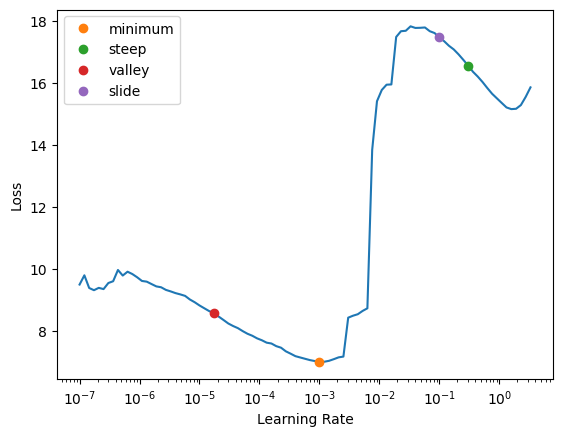

In [ ]:
learn.lr_find(suggest_funcs=[minimum, steep, valley, slide])

In [ ]:
learn.fit_one_cycle(2, lr_max=1e-05, cbs=fit_cbs)

epoch,train_loss,valid_loss,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,time
0,0.113828,0.050750,0.744975,0.563568,0.701369,0.705880,0.949803,0.954582,0.952009,47:54
1,0.052071,0.011015,0.728931,0.550448,0.686495,0.690533,0.948912,0.948430,0.948447,46:15


/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1473: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed soon, in a future version. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

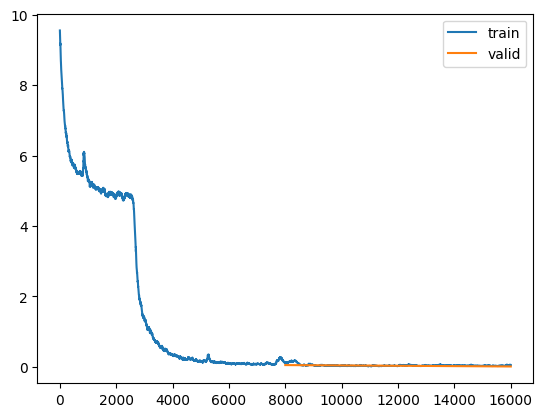

In [ ]:
learn.recorder.plot_loss()

In [ ]:
learn.show_results(learner=learn, input_trunc_at=500, target_trunc_at=250)

,text,target,prediction
0,"du pré performed with the most prestigious orchestras and conductors, including the berlin philharmonic orchestra, london symphony, london philharmonic, new philharmonia orchestra, bbc symphony orchestra, new york philharmonic, philadelphia orchestra, israel philharmonic, and the los angeles philharmonic orchestra.",du pré performed with the most prestigious orchestras and conductors.,"[ du pré performed with the most prestigious orchestras and conductors including the berlin philharmonic orchestra , london symphony orchestra ., The foundations of quantum mechanics were established during the first half of the twentieth century by werner heisenberg , max planck , louis de broglie , albert einstein , niels bohr , erwin schrödinger , and others .]"


In [ ]:
df_test = pd.read_csv('/content/drive/MyDrive/DATA/test_ASSET_preprocess.csv')
df_test.head()

,Unnamed: 0.1,Unnamed: 0,original,simplifications
0,0,0,"one side of the armed conflicts is composed mainly of the sudanese military and the janjaweed , a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region in sudan .","['on one side of the conflicts are the sudanese military and the janjaweed , a sudanese militia group . they are mostly recruited from the afro - arab abbala tribes . ', 'one side of the armed conflicts is composed mainly of the sudanese military and the janjaweed . the janjaweed are a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region in sudan . ', 'one side of the armed conflicts is mainly the sudanese military and the janjaweed militia group . ', 'one side of the war is made up of the sudanese military and the janjaweed , a sudanes..."
1,1,1,"jeddah is the principal gateway to mecca , islam 's holiest city , which able - bodied muslims are required to visit at least once in their lifetime .","['muslims are required to visit mecca once in their lifetime . ', ""able - bodied muslims are required to visit mecca , islam 's holiest city , at least once in their lifetime . "", ""jeddah is the way to mecca , islam 's holiest city , which muslims who are strong enough must visit at least once a lifetime . "", ""jeddah is the principal gateway to mecca , islam 's holiest city . able - bodied muslims are required to visit mecca at least once in their lifetime . "", ""jeddah is the gateway to mecca , islam 's holiest city , which muslims must visit once in their life . "", 'jeddah is the known wa..."
2,2,2,the great dark spot is thought to represent a hole in the methane cloud deck of neptune .,"['the dark spot on ne ;tune may be a hole in the methane clouds . ', ""it is likely that neptune 's great dark spot is a hole in the methane cloud deck . "", 'the great dark spot is a hole in the methane cloud deck of neptune . ', 'the great dark spot is thought to be a hole in the methane cloud deck of neptune . ', ""the great dark spot is thought to be a hole in neptune 's methane clouds . "", 'the great dark spot represents a hole in the methane cloud of neptune . ', 'the great dark spot is believed to be a hole in the methane cloud deck of neptune . ', 'the great dark spot is thought to sh..."
3,3,3,"his next work , saturday , follows an especially eventful day in the life of a successful neurosurgeon .","['next saturday is a presentation of a successful neurosurgeon . ', 'an eventful day in the life of a neurosurgeon is shown in his next work , saturday . ', 'his next workday on saturday is after a busy day as a great neurosurgeon . ', 'his next work , saturday , shows an especially eventful day in the life of a successful neurosurgeon . ', 'saturday follows an eventful day in the life of a neurosurgeon . ', 'saturday tells of an eventful day of a neurosurgeon . ', 'his next work , saturday , follows a very eventful day in the life of a successful neurosurgeon . ', 'his next work , saturda..."
4,4,4,"the tarantula , the trickster character , spun a black cord and , attaching it to the ball , crawled away fast to the east , pulling on the cord with all his strength .","['the tarantula spun a black cord and attached it to the ball . it crawled away fast to the east , pulling on the cord . ', 'the tarantula was the trickster character . it spun a black cord . then it attached the cord to the ball , quickly crawled away and pulled on the ball with all its strength . ', 'the tarantula which is a trickster , spun a black cord , attached it to the ball , crawled away fast to the east and pulled on the cord with all his strength . ', 'the trickster tarantula . spun a black cord and , attaching it to the ball , crawled away fast to the east , pulling on the cord..."


In [ ]:
#Use test data to generate simplifications
df_test['simplified_snt'] = " "

In [ ]:
!pip install swifter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16506 sha256=712a3274b1818c9d2b68c32d44145a4d159aa1e20b272f39f0da9712ff011053
  Stored in directory: /root/.cache/pip/wheels/e4/cf/51/0904952972ee2c7aa3709437065278dc534ec1b8d2ad41b443
Successfully built swifter


In [ ]:
import swifter

# Testing

In [ ]:
#generate simplifications
def simplify (snt):
  output = learn.blurr_generate(snt, num_return_sequences=1)
  final = output[0]['generated_texts']
  return(final)

In [ ]:
df_test['simplified_snt'] = df_test.swifter.apply(lambda row: simplify(row['original']),axis=1)

Pandas Apply:   0%|          | 0/359 [00:00<?, ?it/s]

In [ ]:
df_test

,Unnamed: 0.1,Unnamed: 0,original,simplifications,simplified_snt
0,0,0,"one side of the armed conflicts is composed mainly of the sudanese military and the janjaweed , a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region in sudan .","['on one side of the conflicts are the sudanese military and the janjaweed , a sudanese militia group . they are mostly recruited from the afro - arab abbala tribes . ', 'one side of the armed conflicts is composed mainly of the sudanese military and the janjaweed . the janjaweed are a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region in sudan . ', 'one side of the armed conflicts is mainly the sudanese military and the janjaweed militia group . ', 'one side of the war is made up of the sudanese military and the janjaweed , a sudanes...",The janjaweed is a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region insudan .
1,1,1,"jeddah is the principal gateway to mecca , islam 's holiest city , which able - bodied muslims are required to visit at least once in their lifetime .","['muslims are required to visit mecca once in their lifetime . ', ""able - bodied muslims are required to visit mecca , islam 's holiest city , at least once in their lifetime . "", ""jeddah is the way to mecca , islam 's holiest city , which muslims who are strong enough must visit at least once a lifetime . "", ""jeddah is the principal gateway to mecca , islam 's holiest city . able - bodied muslims are required to visit mecca at least once in their lifetime . "", ""jeddah is the gateway to mecca , islam 's holiest city , which muslims must visit once in their life . "", 'jeddah is the known wa...","jeddah is the principal gateway to mecca , islam 's holiest city ."
2,2,2,the great dark spot is thought to represent a hole in the methane cloud deck of neptune .,"['the dark spot on ne ;tune may be a hole in the methane clouds . ', ""it is likely that neptune 's great dark spot is a hole in the methane cloud deck . "", 'the great dark spot is a hole in the methane cloud deck of neptune . ', 'the great dark spot is thought to be a hole in the methane cloud deck of neptune . ', ""the great dark spot is thought to be a hole in neptune 's methane clouds . "", 'the great dark spot represents a hole in the methane cloud of neptune . ', 'the great dark spot is believed to be a hole in the methane cloud deck of neptune . ', 'the great dark spot is thought to sh...",The great dark spot is thought to represent a hole in the methane cloud deck of neptune
3,3,3,"his next work , saturday , follows an especially eventful day in the life of a successful neurosurgeon .","['next saturday is a presentation of a successful neurosurgeon . ', 'an eventful day in the life of a neurosurgeon is shown in his next work , saturday . ', 'his next workday on saturday is after a busy day as a great neurosurgeon . ', 'his next work , saturday , shows an especially eventful day in the life of a successful neurosurgeon . ', 'saturday follows an eventful day in the life of a neurosurgeon . ', 'saturday tells of an eventful day of a neurosurgeon . ', 'his next work , saturday , follows a very eventful day in the life of a successful neurosurgeon . ', 'his next work , saturda...",his next work follows an especially eventful day in the life of a successful neurosurgeon .
4,4,4,"the tarantula , the trickster character , spun a black cord and , attaching it to the ball , crawled away fast to the east , pulling on the cord with all his strength .","['the tarantula spun a black cord and attached it to the ball . it crawled away fast to the east , pulling on the cord . ', 'the tarantula was the trickster character . it spun a black cord . then it attached the cord to the ball , quickly crawled away and pulled on the ball with all its strength . ', 'the tarantula which is a trickster , spun a black cord ,

In [ ]:
df_test.to_csv('/content/drive/MyDrive/DATA/assetNewConfigBeta250_epoch2_testingTSVAEBARTori_FusionDualMeanPooling.csv')
df_test.head()

,Unnamed: 0.1,Unnamed: 0,original,simplifications,simplified_snt
0,0,0,"one side of the armed conflicts is composed mainly of the sudanese military and the janjaweed , a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region in sudan .","['on one side of the conflicts are the sudanese military and the janjaweed , a sudanese militia group . they are mostly recruited from the afro - arab abbala tribes . ', 'one side of the armed conflicts is composed mainly of the sudanese military and the janjaweed . the janjaweed are a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region in sudan . ', 'one side of the armed conflicts is mainly the sudanese military and the janjaweed militia group . ', 'one side of the war is made up of the sudanese military and the janjaweed , a sudanes...",The janjaweed is a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region insudan .
1,1,1,"jeddah is the principal gateway to mecca , islam 's holiest city , which able - bodied muslims are required to visit at least once in their lifetime .","['muslims are required to visit mecca once in their lifetime . ', ""able - bodied muslims are required to visit mecca , islam 's holiest city , at least once in their lifetime . "", ""jeddah is the way to mecca , islam 's holiest city , which muslims who are strong enough must visit at least once a lifetime . "", ""jeddah is the principal gateway to mecca , islam 's holiest city . able - bodied muslims are required to visit mecca at least once in their lifetime . "", ""jeddah is the gateway to mecca , islam 's holiest city , which muslims must visit once in their life . "", 'jeddah is the known wa...","jeddah is the principal gateway to mecca , islam 's holiest city ."
2,2,2,the great dark spot is thought to represent a hole in the methane cloud deck of neptune .,"['the dark spot on ne ;tune may be a hole in the methane clouds . ', ""it is likely that neptune 's great dark spot is a hole in the methane cloud deck . "", 'the great dark spot is a hole in the methane cloud deck of neptune . ', 'the great dark spot is thought to be a hole in the methane cloud deck of neptune . ', ""the great dark spot is thought to be a hole in neptune 's methane clouds . "", 'the great dark spot represents a hole in the methane cloud of neptune . ', 'the great dark spot is believed to be a hole in the methane cloud deck of neptune . ', 'the great dark spot is thought to sh...",The great dark spot is thought to represent a hole in the methane cloud deck of neptune
3,3,3,"his next work , saturday , follows an especially eventful day in the life of a successful neurosurgeon .","['next saturday is a presentation of a successful neurosurgeon . ', 'an eventful day in the life of a neurosurgeon is shown in his next work , saturday . ', 'his next workday on saturday is after a busy day as a great neurosurgeon . ', 'his next work , saturday , shows an especially eventful day in the life of a successful neurosurgeon . ', 'saturday follows an eventful day in the life of a neurosurgeon . ', 'saturday tells of an eventful day of a neurosurgeon . ', 'his next work , saturday , follows a very eventful day in the life of a successful neurosurgeon . ', 'his next work , saturda...",his next work follows an especially eventful day in the life of a successful neurosurgeon .
4,4,4,"the tarantula , the trickster character , spun a black cord and , attaching it to the ball , crawled away fast to the east , pulling on the cord with all his strength .","['the tarantula spun a black cord and attached it to the ball . it crawled away fast to the east , pulling on the cord . ', 'the tarantula was the trickster character . it spun a black cord . then it attached the cord to the ball , quickly crawled away and pulled on the ball with all its strength . ', 'the tarantula which is a trickster , spun a black cord ,

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/DATA/assetNewConfigBeta250_epoch2_testingTSVAEBARTori_FusionDualMeanPooling.csv')
df.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,original,simplifications,simplified_snt
0,0,0,0,"one side of the armed conflicts is composed mainly of the sudanese military and the janjaweed , a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region in sudan .","['on one side of the conflicts are the sudanese military and the janjaweed , a sudanese militia group . they are mostly recruited from the afro - arab abbala tribes . ', 'one side of the armed conflicts is composed mainly of the sudanese military and the janjaweed . the janjaweed are a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region in sudan . ', 'one side of the armed conflicts is mainly the sudanese military and the janjaweed militia group . ', 'one side of the war is made up of the sudanese military and the janjaweed , a sudanes...",The janjaweed is a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region insudan .
1,1,1,1,"jeddah is the principal gateway to mecca , islam 's holiest city , which able - bodied muslims are required to visit at least once in their lifetime .","['muslims are required to visit mecca once in their lifetime . ', ""able - bodied muslims are required to visit mecca , islam 's holiest city , at least once in their lifetime . "", ""jeddah is the way to mecca , islam 's holiest city , which muslims who are strong enough must visit at least once a lifetime . "", ""jeddah is the principal gateway to mecca , islam 's holiest city . able - bodied muslims are required to visit mecca at least once in their lifetime . "", ""jeddah is the gateway to mecca , islam 's holiest city , which muslims must visit once in their life . "", 'jeddah is the known wa...","jeddah is the principal gateway to mecca , islam 's holiest city ."
2,2,2,2,the great dark spot is thought to represent a hole in the methane cloud deck of neptune .,"['the dark spot on ne ;tune may be a hole in the methane clouds . ', ""it is likely that neptune 's great dark spot is a hole in the methane cloud deck . "", 'the great dark spot is a hole in the methane cloud deck of neptune . ', 'the great dark spot is thought to be a hole in the methane cloud deck of neptune . ', ""the great dark spot is thought to be a hole in neptune 's methane clouds . "", 'the great dark spot represents a hole in the methane cloud of neptune . ', 'the great dark spot is believed to be a hole in the methane cloud deck of neptune . ', 'the great dark spot is thought to sh...",The great dark spot is thought to represent a hole in the methane cloud deck of neptune
3,3,3,3,"his next work , saturday , follows an especially eventful day in the life of a successful neurosurgeon .","['next saturday is a presentation of a successful neurosurgeon . ', 'an eventful day in the life of a neurosurgeon is shown in his next work , saturday . ', 'his next workday on saturday is after a busy day as a great neurosurgeon . ', 'his next work , saturday , shows an especially eventful day in the life of a successful neurosurgeon . ', 'saturday follows an eventful day in the life of a neurosurgeon . ', 'saturday tells of an eventful day of a neurosurgeon . ', 'his next work , saturday , follows a very eventful day in the life of a successful neurosurgeon . ', 'his next work , saturda...",his next work follows an especially eventful day in the life of a successful neurosurgeon .
4,4,4,4,"the tarantula , the trickster character , spun a black cord and , attaching it to the ball , crawled away fast to the east , pulling on the cord with all his strength .","['the tarantula spun a black cord and attached it to the ball . it crawled away fast to the east , pulling on the cord . ', 'the tarantula was the trickster character . it spun a black cord . then it attached the cord to the ball , quickly crawled away and pulled on the ball with all its strength . ', 'the tarantula which is a trickste

# Evaluation

In [ ]:
!pip install rouge-score
!pip install torchmetrics[text]
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.2/840.2 kB 15.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.2/583.2 kB 29.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 52.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.7/581.7 kB 24.9 MB/s eta 0:00:00
  Created wheel for ipadic: filename=ipadic-1.0.0-py3-none-any.whl size=13556704 sha256=8768a8a825962bd94ffa42b488158c34b5649d6893a2c3b65ed78ebd8c02c761
  Stored in directory: /root/.cache/pip/wheels/5b/ea/e3/2f6e0860a327daba3b030853fce4483ed37468bbf1101c59c3
  Created wheel for mecab-ko-dic: filename=mecab_ko_dic-1.0.0-py3-none-any.whl size=33424393 sha256=7cc1b3a7c59906038c359e3426b2cf9458400516af98d069294a77b0ebb662ec
  Stored in directory: /root/.cache/pip/wheels/0d/46/b8/996432c9998690a5a66fb82f649

In [ ]:
from rouge_score import rouge_scorer
from datasets import load_metric
#source : https://pypi.org/project/rouge-score/

reference = df['simplifications'].to_list()
candidate = df['simplified_snt'].to_list()
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2'], use_stemmer=False)
rouge_val = scorer.score(''.join(reference),''.join(candidate))
print(rouge_val)

{'rouge1': Score(precision=0.9836862200624783, recall=0.09337418865935225, fmeasure=0.1705584978334136), 'rouge2': Score(precision=0.907481340045131, recall=0.08612708192616267, fmeasure=0.15732298155336885)}


In [ ]:
!pip install evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
import evaluate
import numpy as np
from nltk.tokenize import RegexpTokenizer

rouge_metric = evaluate.load("rouge")

# define function for custom tokenization
def tokenize_sentence(arg):
  encoded_arg = tokenizer(arg)
  return tokenizer.convert_ids_to_tokens(encoded_arg.input_ids)

# define function to get ROUGE scores with custom tokenization
def metrics_func(eval_arg):
  preds, labels = eval_arg
  return rouge_metric.compute(
    predictions=preds,
    references=labels,
    tokenizer=tokenize_sentence
  )

In [ ]:
!pip install rouge

In [ ]:
import nltk
from rouge import Rouge

nltk.download('punkt')

rouge = Rouge()
for index, row in df.iterrows():
    reference = row['simplifications']
    generated = row['simplified_snt']

    scores = rouge.get_scores(generated, reference)

    # Access the ROUGE scores
    rouge_1 = scores[0]['rouge-1']['f']
    rouge_2 = scores[0]['rouge-2']['f']
    rouge_l = scores[0]['rouge-l']['f']

    # Do something with the scores, such as storing them in a new column of the dataframe
    df.loc[index, 'rouge-1'] = rouge_1
    df.loc[index, 'rouge-2'] = rouge_2
    df.loc[index, 'rouge-l'] = rouge_l


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
df

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,original,simplifications,simplified_snt,rouge-1,rouge-2,rouge-l
0,0,0,0,"one side of the armed conflicts is composed mainly of the sudanese military and the janjaweed , a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region in sudan .","['on one side of the conflicts are the sudanese military and the janjaweed , a sudanese militia group . they are mostly recruited from the afro - arab abbala tribes . ', 'one side of the armed conflicts is composed mainly of the sudanese military and the janjaweed . the janjaweed are a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region in sudan . ', 'one side of the armed conflicts is mainly the sudanese military and the janjaweed militia group . ', 'one side of the war is made up of the sudanese military and the janjaweed , a sudanes...",The janjaweed is a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region insudan .,0.487179,0.287879,0.487179
1,1,1,1,"jeddah is the principal gateway to mecca , islam 's holiest city , which able - bodied muslims are required to visit at least once in their lifetime .","['muslims are required to visit mecca once in their lifetime . ', ""able - bodied muslims are required to visit mecca , islam 's holiest city , at least once in their lifetime . "", ""jeddah is the way to mecca , islam 's holiest city , which muslims who are strong enough must visit at least once a lifetime . "", ""jeddah is the principal gateway to mecca , islam 's holiest city . able - bodied muslims are required to visit mecca at least once in their lifetime . "", ""jeddah is the gateway to mecca , islam 's holiest city , which muslims must visit once in their life . "", 'jeddah is the known wa...","jeddah is the principal gateway to mecca , islam 's holiest city .",0.318841,0.192308,0.318841
2,2,2,2,the great dark spot is thought to represent a hole in the methane cloud deck of neptune .,"['the dark spot on ne ;tune may be a hole in the methane clouds . ', ""it is likely that neptune 's great dark spot is a hole in the methane cloud deck . "", 'the great dark spot is a hole in the methane cloud deck of neptune . ', 'the great dark spot is thought to be a hole in the methane cloud deck of neptune . ', ""the great dark spot is thought to be a hole in neptune 's methane clouds . "", 'the great dark spot represents a hole in the methane cloud of neptune . ', 'the great dark spot is believed to be a hole in the methane cloud deck of neptune . ', 'the great dark spot is thought to sh...",The great dark spot is thought to represent a hole in the methane cloud deck of neptune,0.588235,0.400000,0.588235
3,3,3,3,"his next work , saturday , follows an especially eventful day in the life of a successful neurosurgeon .","['next saturday is a presentation of a successful neurosurgeon . ', 'an eventful day in the life of a neurosurgeon is shown in his next work , saturday . ', 'his next workday on saturday is after a busy day as a great neurosurgeon . ', 'his next work , saturday , shows an especially eventful day in the life of a successful neurosurgeon . ', 'saturday follows an eventful day in the life of a neurosurgeon . ', 'saturday tells of an eventful day of a neurosurgeon . ', 'his next work , saturday , follows a very eventful day in the life of a successful neurosurgeon . ', 'his next work , saturda...",his next work follows an especially eventful day in the life of a successful neurosurgeon .,0.555556,0.325000,0.518519
4,4,4,4,"the tarantula , the trickster character , spun a black cord and , attaching it to the ball , crawled away fast to the east , pulling on the cord with all his strength .","['the tarantula spun a black cord and attached it to the ball . it crawled away fast to the east , pulling on the cord . ', 'the tarantula was the trickster character . it spun a black cord . then it attac

In [ ]:
np.mean(df['rouge-1'])

0.5017162100686952

In [ ]:
np.mean(df['rouge-2'])

0.31203257932118134

In [ ]:
np.mean(df['rouge-l'])

0.49780052522572965

In [ ]:
from nltk.translate.bleu_score import sentence_bleu
import ast
#source : https://www.nltk.org/_modules/nltk/translate/bleu_score.html

reference = df['simplifications']
candidate = df['simplified_snt']

if len(reference) != len(candidate):
    raise ValueError('The number of sentences in both files do not match.')

score = 0.

for i in range(len(reference)):
  ref = ast.literal_eval(reference[i])
  for j in range(len(ref)):
    score += sentence_bleu([ref[j].strip().split()], candidate[i].strip().split())

    # print(i, reference[i], candidate[i], sentence_bleu([reference[i].strip().split()], candidate[i].strip().split()))

score /= len(reference)*8
print("The bleu score is: "+str(score*100))

/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

The bleu score is: 42.37154493693746


In [ ]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
from statistics import mean
import sys


global sm_func
sm_func = {}
sm_func["None"] = None
sm_func["sm1"] = SmoothingFunction().method1
sm_func["sm2"] = SmoothingFunction().method2
sm_func["sm3"] = SmoothingFunction().method3
sm_func["sm4"] = SmoothingFunction().method4
sm_func["sm5"] = SmoothingFunction().method5
sm_func["sm6"] = SmoothingFunction().method6
sm_func["sm7"] = SmoothingFunction().method7


class BLEU(object):


    def compute_bleu(self, refs, systems, sm):
        bleu_1 = []
        bleu_2 = []
        bleu_3 = []
        bleu_4 = []
        bleu_all = []
        for i in range(len(systems)):
            B1 = sentence_bleu(refs[i].split(), systems[i].split(), weights = (1, 0, 0, 0), smoothing_function=sm)
            bleu_1.append(float(B1))
            B2 = sentence_bleu(refs[i].split(), systems[i].split(), weights = (0, 1, 0, 0), smoothing_function=sm)
            bleu_2.append(float(B2))
            B3 = sentence_bleu(refs[i].split(), systems[i].split(), weights = (0, 0, 1, 0), smoothing_function=sm)
            bleu_3.append(float(B3))
            B4 = sentence_bleu(refs[i].split(), systems[i].split(), weights = (0, 0, 0, 1), smoothing_function=sm)
            bleu_4.append(float(B4))
            BA = sentence_bleu(refs[i].split(), systems[i].split(), weights = (0.25, 0.25, 0.25, 0.25), smoothing_function=sm)
            bleu_all.append(float(BA))
        return mean(bleu_1), mean(bleu_2), mean(bleu_3), mean(bleu_4), mean(bleu_all)

    def print_score(self, references, systems, sm):

        gen = open(systems, 'r', encoding='utf-8')
        ref = open(references, 'r', encoding='utf-8')

        gen_corpus = []
        ref_corpus = []

        for g, r in zip(gen, ref):
            gen_corpus.append(g.strip())
            ref_corpus.append(r.strip())


        b1, b2, b3, b4, ba = self.compute_bleu(ref_corpus, gen_corpus, sm_func[sm])
        print("------------------------------------------")
        print("S_FUNC: %s, BLEU-ALL: %02.3f, BLEU-1: %02.3f, BLEU-2: %02.3f, BLEU-3: %02.3f, BLEU-4: %02.3f" \
            %(sm, ba * 100, b1 * 100, b2 * 100, b3 * 100, b4 * 100))
        gen.close()
        ref.close()

bleu = BLEU()
sm = "sm7"

reference = df['simplifications'].to_list()
gen = df['simplified_snt'].to_list()

gen_corpus = []
ref_corpus = []

ref = []
for i in range(len(reference)):
  ref = ast.literal_eval(reference[i])
  for j in range(len(ref)):
          gen_corpus.append(gen[i])
          ref_corpus.append(ref[j])


b1, b2, b3, b4, ba = bleu.compute_bleu(ref_corpus, gen_corpus, sm_func[sm])
print("------------------------------------------")
print("S_FUNC: %s, BLEU-ALL: %02.3f, BLEU-1: %02.3f, BLEU-2: %02.3f, BLEU-3: %02.3f, BLEU-4: %02.3f" \
      %(sm, ba * 100, b1 * 100, b2 * 100, b3 * 100, b4 * 100))
# gen.close()

------------------------------------------
S_FUNC: sm7, BLEU-ALL: 7.870, BLEU-1: 36.222, BLEU-2: 12.890, BLEU-3: 4.739, BLEU-4: 1.735


In [ ]:
!pip install transformers

In [ ]:
!pip install bert_score

In [ ]:
import ast
# from torchmetrics.text.bert import BERTScore
import torch
from evaluate import load
bertscore = load("bertscore")
reference = df['simplifications'].to_list()
candidate = df['simplified_snt'].to_list()
# bertscore = BERTScore()
precision = 0.
recall = 0.
f1 = 0.

for i in range(0,len(reference)):
  ref = ast.literal_eval(reference[i])
  for j in range(0,len(ref)):
    print(candidate[i])
    print(ref[j])
    score = bertscore.compute(predictions=[candidate[i]], references=[ref[j]], lang="en")
    # score = bertscore([candidate[i]],[ref[j]])
    print(score)
    precision += score['precision'][0]
    recall += score['recall'][0]
    f1 += score['f1'][0]

Streaming output truncated to the last 5000 lines.
mk sun grew up to be a lawyer like his idol , brandon ( waise lee ) . 
{'precision': [0.9303497076034546], 'recall': [0.9415475130081177], 'f1': [0.9359151124954224], 'hashcode': 'roberta-large_L17_no-idf_version=0.3.12(hug_trans=4.35.2)'}
 the lawyer , brandon ( waise lee ) became his idol , and mk sun grew up to be a lawyer
the lawyer , brandon ( waise lee ) , became mk sun 's idol , and he grew up to be a lawyer as well . 
{'precision': [0.9444985389709473], 'recall': [0.9279093742370605], 'f1': [0.9361304640769958], 'hashcode': 'roberta-large_L17_no-idf_version=0.3.12(hug_trans=4.35.2)'}
 the lawyer , brandon ( waise lee ) became his idol , and mk sun grew up to be a lawyer
the lawyer , brandon ( waise lee ) , became his idol , and mk sun became lawyer . 
{'precision': [0.946297287940979], 'recall': [0.9569635987281799], 'f1': [0.9516005516052246], 'hashcode': 'roberta-large_L17_no-idf_version=0.3.12(hug_trans=4.35.2)'}
 the lawyer

In [ ]:
precision /= (len(reference)*10)
print("The precision is: "+str(precision*100))

recall /= (len(reference)*10)
print("The recall is: "+str(recall*100))

f1 /= (len(reference)*10)
print("The f1 is: "+str(f1*100))

The precision is: 94.07913991501736
The recall is: 93.96583853823893
The f1 is: 93.99657746045371


In [ ]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 2.0 MB/s eta 0:00:00


In [ ]:
from evaluate import load
import ast
sari = load("sari")
sources=df['original']
predictions=df['simplified_snt']
references=df['simplifications'].to_list()

sari_score = 0.

for i in range(0,len(sources)):
    ref = ast.literal_eval(references[i])
    print(predictions[i])
    print(ref)
    score = sari.compute(sources=[sources[i]], predictions=[predictions[i]], references=[ref])
    print(score)
    sari_score += score['sari']

sari_score /= (len(sources))
print("The sari_score is: "+str(sari_score))

The janjaweed is a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region insudan .
['on one side of the conflicts are the sudanese military and the janjaweed , a sudanese militia group . they are mostly recruited from the afro - arab abbala tribes . ', 'one side of the armed conflicts is composed mainly of the sudanese military and the janjaweed . the janjaweed are a sudanese militia group recruited mostly from the afro - arab abbala tribes of the northern rizeigat region in sudan . ', 'one side of the armed conflicts is mainly the sudanese military and the janjaweed militia group . ', 'one side of the war is made up of the sudanese military and the janjaweed , a sudanese militia group from the afro - arab abbala tribes of the northern rizeigat region in sudan . ', 'one side of the war is mainly made up of the sudanese military and the janjaweed . the janjaweed is a sudanese militia group who come mostly from the afro - arab abbala t